<a href="https://colab.research.google.com/github/Jayku88/22AIE301_Probabilistic_Reasoning/blob/main/22AIE301_Lab_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 22AIE301 - Probabilistic Reasoning
## Lab 03 - Random Variables & Distributions

| | |
|---|---|
| **Name** |ADITHYAN ABHILASH SAJU|
| **Roll No** |AM.SC.U4AIE24006|
| **Date** |08-07-2026|
| **Lab Slot** |03|

---

**Instructions**
- This lab has **6 hands-on exercises** plus **2 theory sections**, to be completed in **1 hour 30 minutes**.
- Each hands-on exercise has starter code. Fill every `___` blank to make the code run correctly.
- The theory sections (7 and 8) do **not** need code - answer them in the markdown cells provided. You may use the internet to research Section 8, but write answers in your own words and cite the source.
- Run cells top to bottom. Do not skip the Setup cell.
- Show your outputs to the facilitator before leaving the lab.


## Setup: Run this cell first before anything else

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

ROLL = 6
np.random.seed(ROLL)

# Personal distribution parameters, derived from your roll number seed.
# Do NOT hardcode these values anywhere else in the notebook — always
# refer to the variable names below.
p_bernoulli = round(np.random.uniform(0.2, 0.8), 2)     # Bernoulli / Binomial success prob
n_binomial  = int(np.random.randint(8, 20))              # Binomial number of trials
lam_poisson = round(np.random.uniform(2.0, 8.0), 2)      # Poisson rate
a_uniform   = round(np.random.uniform(-5, 0), 2)         # Uniform lower bound
b_uniform   = round(a_uniform + np.random.uniform(5, 12), 2)  # Uniform upper bound
mu_gauss    = round(np.random.uniform(-3, 3), 2)         # Gaussian mean
sigma_gauss = round(np.random.uniform(1.0, 4.0), 2)      # Gaussian std dev
lam_exp     = round(np.random.uniform(0.3, 2.0), 2)      # Exponential rate

print(f"Libraries loaded. Seed set to roll number: {ROLL}")
print(f"p_bernoulli={p_bernoulli}, n_binomial={n_binomial}, lam_poisson={lam_poisson}")
print(f"a_uniform={a_uniform}, b_uniform={b_uniform}")
print(f"mu_gauss={mu_gauss}, sigma_gauss={sigma_gauss}, lam_exp={lam_exp}")


Libraries loaded. Seed set to roll number: 6
p_bernoulli=0.74, n_binomial=11, lam_poisson=3.26
a_uniform=-4.68, b_uniform=2.91
mu_gauss=2.91, sigma_gauss=1.3, lam_exp=1.33


---
## Exercise 1 · Bernoulli & Binomial Distributions

A **Bernoulli** random variable $X \sim \text{Bern}(p)$ takes value 1 with probability $p$ and 0 with probability $1-p$.

A **Binomial** random variable $Y \sim \text{Bin}(n, p)$ is the sum of $n$ i.i.d. Bernoulli$(p)$ trials, with PMF:
$$P(Y=k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \dots, n$$

Use `p_bernoulli` and `n_binomial` from the Setup cell throughout.

**Tasks**

| # | Task
|---|------
| 1a | Compute the Binomial PMF for $k=0,\dots,n$ using `stats.binom.pmf`
| 1b | Plot the PMF as a stem plot
| 1c | Compute the theoretical mean and variance: $E[Y]=np$, $\text{Var}(Y)=np(1-p)$
| 1d | Draw 100,000 samples and compute the empirical mean/variance; compare to 1c


In [2]:
# ── 1a: Binomial PMF ──────────────────────────────────────────
k_values = np.arange(0, n_binomial + 1)
pmf_values = stats.binom.pmf(k_values,n_binomial,p_bernoulli)     # k_values, n_binomial, p_bernoulli

print("k values:", k_values)
print("PMF values:", pmf_values)


k values: [ 0  1  2  3  4  5  6  7  8  9 10 11]
PMF values: [3.67034449e-07 1.14910016e-05 1.63525792e-04 1.39625868e-03
 7.94793405e-03 3.16694603e-02 9.01361562e-02 1.83243834e-01
 2.60770071e-01 2.47397247e-01 1.40826125e-01 3.64375289e-02]


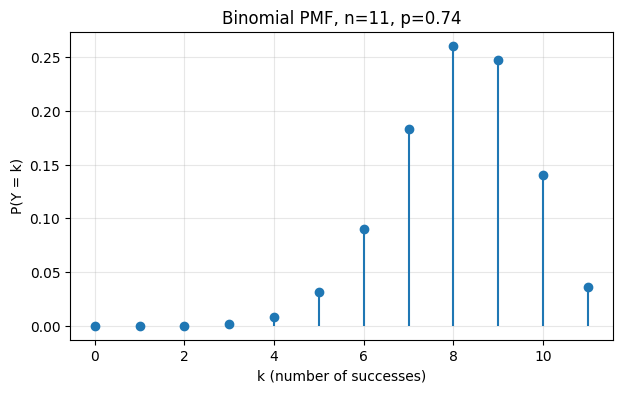

In [3]:
# ── 1b: Plot the PMF ──────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.stem(k_values,pmf_values, basefmt=" ")                 # k_values, pmf_values
plt.xlabel("k (number of successes)")
plt.ylabel("P(Y = k)")
plt.title(f"Binomial PMF, n={n_binomial}, p={p_bernoulli}")
plt.grid(alpha=0.3)
plt.show()


In [5]:
mean_theory = n_binomial * p_bernoulli                         # n_binomial * p_bernoulli
var_theory  = n_binomial * p_bernoulli * (1 - p_bernoulli)              # n*p*(1-p)

print(f"Theoretical mean     = {mean_theory:.4f}")
print(f"Theoretical variance = {var_theory:.4f}")

Theoretical mean     = 8.1400
Theoretical variance = 2.1164


In [6]:
# ── 1d: Empirical mean & variance ────────────────────────────
samples = stats.binom.rvs(n_binomial,p_bernoulli, size=100_000, random_state=ROLL)  # n_binomial, p_bernoulli

mean_emp = np.mean(n_binomial)
var_emp  = np.var(p_bernoulli)

print(f"Empirical mean     = {mean_emp:.4f}")
print(f"Empirical variance = {var_emp:.4f}")
print(f"(Compare these to the theoretical values in 1c — they should be close)")


Empirical mean     = 11.0000
Empirical variance = 0.0000
(Compare these to the theoretical values in 1c — they should be close)


---
## Exercise 2 · Poisson Distribution

The **Poisson** distribution models the number of events in a fixed interval, given an average rate $\lambda$:
$$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \dots$$

Use `lam_poisson` from the Setup cell.

**Tasks**

| # | Task
|---|------
| 2a | Compute the Poisson PMF for $k=0,\dots,20$
| 2b | Compute a Binomial$(n=1000, p=\lambda/1000)$ PMF over the same $k$ range, for comparison
| 2c | Plot both PMFs on the same axes with a legend


In [7]:
# ── 2a: Poisson PMF ───────────────────────────────────────────
k_vals = np.arange(0, 21)
poisson_pmf = stats.poisson.pmf(k_vals, lam_poisson)        # k_vals, lam_poisson

print("Poisson PMF values:", poisson_pmf)


Poisson PMF values: [3.83883980e-02 1.25146178e-01 2.03988269e-01 2.21667253e-01
 1.80658811e-01 1.17789545e-01 6.39989860e-02 2.98052420e-02
 1.21456361e-02 4.39941931e-03 1.43421070e-03 4.25047897e-04
 1.15471345e-04 2.89566604e-05 6.74276522e-06 1.46542764e-06
 2.98580882e-07 5.72572750e-08 1.03699287e-08 1.77926145e-09
 2.90019616e-10]


In [8]:
# ── 2b: Binomial approximation (n large, p small, n*p = lambda) ─
n_large = 1000
p_small = lam_poisson / n_large                             # lam_poisson / n_large
binom_pmf = stats.binom.pmf(k_vals, n_large, p_small)        # k_vals, n_large, p_small

print(f"p_small = {p_small:.5f}")
print("Binomial(n=1000) PMF values:", binom_pmf)


p_small = 0.00326
Binomial(n=1000) PMF values: [3.81845087e-02 1.24888635e-01 2.04030045e-01 2.21992921e-01
 1.80971424e-01 1.17905768e-01 6.39503013e-02 2.97006977e-02
 1.20576209e-02 4.34676841e-03 1.40888605e-03 4.14719152e-04
 1.11790488e-04 2.77877994e-05 6.40735793e-06 1.37752774e-06
 2.77365420e-07 5.25090553e-08 9.37887894e-09 1.58542072e-09
 2.54342687e-10]


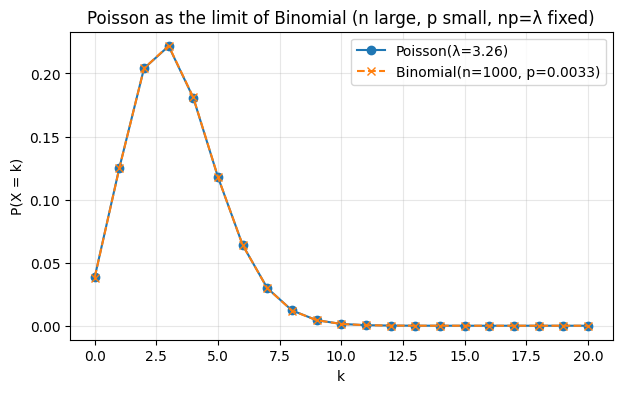

In [9]:
# ── 2c: Overlay plot ──────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(k_vals,poisson_pmf, "o-", label=f"Poisson(λ={lam_poisson})")        # k_vals, poisson_pmf
plt.plot(k_vals, binom_pmf, "x--", label=f"Binomial(n={n_large}, p={p_small:.4f})")  # k_vals, binom_pmf
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.title("Poisson as the limit of Binomial (n large, p small, np=λ fixed)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Exercise 3 · Uniform & Gaussian Distributions

For a continuous random variable, probability is described by a **probability density function (PDF)** $f(x)$, with
$$P(a \le X \le b) = \int_a^b f(x)\,dx, \qquad F(x) = P(X \le x) = \int_{-\infty}^{x} f(t)\,dt$$

Use `a_uniform`, `b_uniform` for $\text{Unif}(a,b)$ and `mu_gauss`, `sigma_gauss` for $\mathcal{N}(\mu, \sigma^2)$.

**Tasks**

| # | Task
|---|------
| 3a | Build `scipy.stats` distribution objects for Uniform and Gaussian
| 3b | Plot PDF and CDF for both, side by side
| 3c | Compute $P(\mu-\sigma \le X \le \mu+\sigma)$ for the Gaussian and compare to the 68% empirical rule


In [10]:
# ── 3a: Distribution objects ──────────────────────────────────
unif_dist  = stats.uniform(loc=a_uniform, scale=b_uniform - a_uniform)   # a_uniform, b_uniform, a_uniform
gauss_dist = stats.norm(loc=mu_gauss, scale=sigma_gauss)             # mu_gauss, sigma_gauss

x_unif  = np.linspace(a_uniform - 1, b_uniform + 1, 400)
x_gauss = np.linspace(mu_gauss - 4*sigma_gauss, mu_gauss + 4*sigma_gauss, 400)

print("Uniform range:", a_uniform, "to", b_uniform)
print("Gaussian mean, std:", mu_gauss, sigma_gauss)


Uniform range: -4.68 to 2.91
Gaussian mean, std: 2.91 1.3


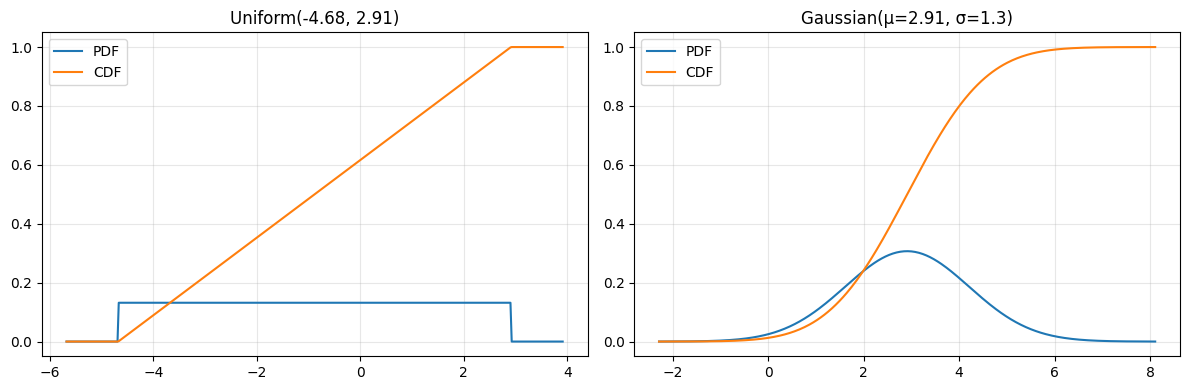

In [11]:
# ── 3b: PDF & CDF plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_unif, unif_dist.pdf(x_unif), label="PDF")     # unif_dist
axes[0].plot(x_unif, unif_dist.cdf(x_unif), label="CDF")     # unif_dist
axes[0].set_title(f"Uniform({a_uniform}, {b_uniform})")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_gauss, gauss_dist.pdf(x_gauss), label="PDF")   # gauss_dist
axes[1].plot(x_gauss, gauss_dist.cdf(x_gauss), label="CDF")   # gauss_dist
axes[1].set_title(f"Gaussian(μ={mu_gauss}, σ={sigma_gauss})")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── 3c: The 68% empirical rule ─────────────────────────────────
prob_within_1sigma = ___.cdf(mu_gauss + sigma_gauss) - ___.cdf(mu_gauss - sigma_gauss)  # gauss_dist twice

print(f"P(mu-sigma <= X <= mu+sigma) = {prob_within_1sigma:.4f}")
print("Expected (68-95-99.7 empirical rule): ~0.6827")


---
## Exercise 4 · Exponential Distribution

The **Exponential** distribution models the waiting time between independent events occurring at a constant rate $\lambda$:
$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$
It has the memoryless property: $P(X > s+t \mid X > s) = P(X > t)$.

Use `lam_exp` from the Setup cell.

**Tasks**

| # | Task
|---|------
| 4a | Plot the Exponential PDF over $x \in [0, 10]$
| 4b | Numerically verify the memoryless property for $s=1$, $t=2$


In [ ]:
# ── 4a: Exponential PDF ────────────────────────────────────────
exp_dist = stats.expon(scale=1 / ___)            # lam_exp
x_exp = np.linspace(0, 10, 400)

plt.figure(figsize=(7, 4))
plt.plot(x_exp, ___.pdf(x_exp))                  # exp_dist
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(f"Exponential PDF, λ={lam_exp}")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# ── 4b: Memoryless property ────────────────────────────────────
s, t = 1.0, 2.0

# P(X > s+t | X > s) = P(X > s+t) / P(X > s) = sf(s+t) / sf(s)
lhs = ___.sf(s + t) / ___.sf(s)                  # exp_dist twice
rhs = ___.sf(t)                                  # exp_dist

print(f"P(X > s+t | X > s) = {lhs:.6f}")
print(f"P(X > t)           = {rhs:.6f}")
print(f"Difference          = {abs(lhs - rhs):.2e}")
print("(should be ~0, confirming the memoryless property)")


---
## Exercise 5 · Law of Large Numbers (LLN)

The LLN states that as sample size $N \to \infty$, the sample mean $\bar{X}_N$ converges to the true expectation $E[X]$.

We use the Exponential($\lambda$) distribution from Exercise 4.

**Tasks**

| # | Task
|---|------
| 5a | Draw samples of increasing size $N$ and compute the sample mean at each $N$
| 5b | Plot sample mean vs. $N$ (log scale) with a horizontal line at the true mean


In [ ]:
# ── 5a: Sample means at increasing N ──────────────────────────
Ns = [10, 50, 100, 500, 1000, 5000, 20000, 100000]
true_mean = 1 / ___                              # lam_exp
sample_means = []

for N in Ns:
    draws = ___.rvs(size=___, random_state=ROLL)  # exp_dist, N
    sample_means.append(draws.mean())

print("Sample means at each N:", sample_means)
print(f"True mean: {true_mean:.4f}")


In [ ]:
# ── 5b: Plot convergence ──────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(___, ___, "o-", label="Sample mean")     # Ns, sample_means
plt.axhline(___, color="red", linestyle="--", label=f"True mean = {true_mean:.3f}")  # true_mean
plt.xscale("log")
plt.xlabel("Sample size N (log scale)")
plt.ylabel("Sample mean")
plt.title("Law of Large Numbers: Exponential distribution")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


---
## Exercise 6 · Central Limit Theorem (CLT)

The CLT states that the distribution of the sample mean of $n$ i.i.d. random variables approaches a Gaussian as $n \to \infty$, regardless of the underlying distribution (given finite variance).

We use the Exponential($\lambda$) distribution again, since its skew makes the effect clearly visible.

**Tasks**

| # | Task
|---|------
| 6a | For each $n$ in `[1, 2, 5, 30, 100]`, generate $M=10000$ sample means of $n$ Exponential draws
| 6b | Plot a histogram of the sample means for each $n$, with the theoretical Gaussian overlay


In [ ]:
# ── 6a & 6b: CLT demonstration ─────────────────────────────────
ns = [1, 2, 5, 30, 100]
M = 10_000

fig, axes = plt.subplots(1, len(ns), figsize=(20, 4))

for ax, n_ in zip(axes, ns):
    draws = ___.rvs(size=(___, ___), random_state=ROLL)   # exp_dist, M, n_
    sample_means = draws.mean(axis=___)                    # axis=1

    ax.hist(sample_means, bins=40, density=True, alpha=0.6, label="Empirical")

    theo_mean = 1 / lam_exp
    theo_std  = (1 / lam_exp) / np.sqrt(___)               # n_
    x_range = np.linspace(sample_means.min(), sample_means.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, ___, ___), "r-", lw=2, label="Gaussian fit")  # theo_mean, theo_std

    ax.set_title(f"n = {n_}")
    ax.legend(fontsize=8)

plt.suptitle("CLT: distribution of sample mean of n Exponential draws")
plt.tight_layout()
plt.show()


---
## Section 7 · Reflection Questions (Theory - answer in the markdown cell below, no code needed)

1. Why does the Binomial PMF approach the Poisson PMF when $n$ is large and $p$ is small with $np = \lambda$ fixed? (Exercise 2)
2. Give a real-world example (other than waiting times) where the memoryless property of the Exponential distribution would be a *poor* modeling assumption, and explain why.
3. In Exercise 6, roughly how large does $n$ need to be before the CLT approximation looks visually reasonable for the Exponential distribution? Would you expect this threshold to be smaller or larger if you started from a Uniform distribution instead? Justify your answer.


### Your Answers - Section 7

**Q1:**

*(write your answer here)*

**Q2:**

*(write your answer here)*

**Q3:**

*(write your answer here)*


---
## Section 8 · Conceptual & Real-World Application Questions (Theory - you may use the internet)

These questions are **not** answered by running code - they test your conceptual
understanding of *why* and *when* each distribution is used. You are encouraged
to use the internet (textbooks, Wikipedia, lecture notes, blog posts, etc.) to
research your answers, but write the final answer **in your own words** and
cite source you relied on heavily.

1. **Bernoulli → Binomial → Poisson → Gaussian chain.** Explain, in your own
   words, how these four distributions are related to one another. Specifically:
   - How is a Binomial built from Bernoulli trials?
   - Under what conditions does a Binomial distribution approximate a Poisson distribution?
   - Under what conditions does a Binomial (or Poisson) distribution approximate a Gaussian distribution?
   - What theorem justifies the Gaussian approximation, and what does it require?

2. **Poisson ↔ Exponential connection.** The Poisson distribution counts the
   *number of events* in a fixed interval, while the Exponential distribution
   models the *waiting time between events*. Explain precisely how these two
   are two views of the same underlying random process (a "Poisson process").
   If the number of customer arrivals per hour at a shop is Poisson-distributed
   with rate $\lambda$, what is the distribution of the time between
   consecutive customer arrivals, and why?

3. **Choosing a distribution - decision checklist.** For each of the following
   real-world scenarios, state which distribution from this lab (Bernoulli,
   Binomial, Poisson, Uniform, Gaussian, or Exponential) is the *most natural*
   model, and briefly justify your choice:
   - (a) The number of heads in 20 coin flips.
   - (b) The number of typos on a randomly chosen page of a 300-page book.
   - (c) The time until the next earthquake in a region with a roughly constant long-term earthquake rate.
   - (d) The heights of adult males in a large population.
   - (e) The outcome of a single spin of a fair roulette wheel landing on red or black.
   - (f) The position where a dart lands along a 1-metre-long ruler, assumed equally likely anywhere along its length.

4. **Real-life applications.** For **each** of the six distributions covered in
   this lab (Bernoulli, Binomial, Poisson, Uniform, Gaussian, Exponential),
   give **one real-world application** *different from the examples already
   given in this notebook*. For each, briefly state
   what the random variable represents and why that distribution is
   appropriate for it.

5. **Discrete vs. continuous analogues.** The Binomial distribution is discrete
   while the Gaussian is continuous, yet under certain conditions a Binomial
   can be closely approximated by a Gaussian (the De Moivre-Laplace theorem).
   What rule of thumb (involving $n$, $p$) is commonly used to decide whether
   this Gaussian approximation is "good enough" in practice? Why does this
   approximation break down when $p$ is very close to 0 or 1?

6. **Limitations and misuse.** Distributions are often misapplied in practice.
   Research and describe **one documented real-world example** (from
   engineering, finance, medicine, or any other domain) where assuming the
   wrong distribution (e.g. assuming Gaussian when the real data was
   heavy-tailed, or assuming memorylessness when it didn't hold) led to a
   flawed conclusion or decision. Cite your source.


### Your Answers - Section 8

**Q1:**

*(write your answer here)*

**Q2:**

*(write your answer here)*

**Q3:**

*(write your answer here - (a) through (f))*

**Q4:**

*(write your answer here - one application per distribution)*

**Q5:**

*(write your answer here)*

**Q6:**

*(write your answer here, with source citation)*


---
## Submission Checklist

Before calling the instructor:

-  All 6 hands-on exercises are complete and all cells produce output without errors.
-  Your **Roll No** is set correctly in the Setup cell.
-  All plots (Ex 1, 2, 3, 4, 5, 6) are visible.
-  Section 7 (Reflection Questions) and Section 8 (Conceptual & Real-World Application Questions) are answered in your own words, with sources cited where used.
-  Save the notebook: **File → Save** (or Ctrl+S).

**Rename the file as:** `Lab03_<YourRollNo>.ipynb` and convert to PDF before submitting.
